In [1]:
# Installer Hugging Face Transformers et Datasets
!pip install transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 10.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 41.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 1.0.0rc2
    Uninstalling huggingface-hub-1.0.0rc2:
      Successfully uninstalled huggingface-hub-1.0.0rc2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; p

**Importation des bibliothèques**

In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset

# Pour PyTorch
import torch
from torch.utils.data import DataLoader

**Charger le dataset GoEmotions**

In [3]:
# Charger le dataset GoEmotions (multi-label)
dataset = load_dataset("go_emotions")

README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [4]:
# Afficher un exemple
print(dataset["train"][0])
# Voir la structure
print(dataset)

{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [5]:
# Afficher 3 exemples du dataset d'entraînement
for i in range(3):
    print("Texte :", dataset['train'][i]['text'])
    print("Labels :", dataset['train'][i]['labels'])
    print("---")

Texte : My favourite food is anything I didn't have to cook myself.
Labels : [27]
---
Texte : Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Labels : [27]
---
Texte : WHY THE FUCK IS BAYLESS ISOING
Labels : [2]
---


**Prétraitement / Tokenization pour BERT**

In [6]:
from transformers import BertTokenizer

# Charger le tokenizer BERT "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [7]:
# fonction de prétraitement
def preprocess_data(examples, tokenizer, max_len=64):
    """
    Tokenize le texte et crée des masques d'attention pour BERT
    Convertit les labels en vecteurs binaires multi-label
    """
    # Tokenization
    encoding = tokenizer(
        examples['text'],
        padding='max_length',   # remplir jusqu'à max_len
        truncation=True,        # couper si texte trop long
        max_length=max_len,
        return_tensors='pt'     # retourne des tensors PyTorch
    )

    # Conversion labels en vecteurs binaires
    num_labels = 28
    labels = torch.zeros((len(examples['labels']), num_labels))
    for i, label_list in enumerate(examples['labels']):
        labels[i, label_list] = 1  # 1 si l'émotion est présente

    return encoding, labels

In [8]:
# Fonction pour extraire les textes et labels du dataset Hugging Face
def convert_dataset_to_tensors(dataset_split):
    examples = {
        'text': [x['text'] for x in dataset_split],
        'labels': [x['labels'] for x in dataset_split]
    }
    return preprocess_data(examples, tokenizer)

# Prétraitement pour train, validation, test
train_encodings, train_labels = convert_dataset_to_tensors(dataset['train'])
val_encodings, val_labels = convert_dataset_to_tensors(dataset['validation'])
test_encodings, test_labels = convert_dataset_to_tensors(dataset['test'])

In [9]:
# Créer les DataLoaders PyTorch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

# Créer TensorDataset
train_dataset = TensorDataset(train_encodings['input_ids'],
                              train_encodings['attention_mask'],
                              train_labels)

val_dataset = TensorDataset(val_encodings['input_ids'],
                            val_encodings['attention_mask'],
                            val_labels)

test_dataset = TensorDataset(test_encodings['input_ids'],
                             test_encodings['attention_mask'],
                             test_labels)

# Créer DataLoader
batch_size = 16

train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
test_loader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)

**création et fine-tuning du modèle BERT multi-label**

In [10]:
# Importer le modèle BERT

from transformers import BertForSequenceClassification
from torch.optim import AdamW

# Charger BERT pour classification multi-label
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=28,       # nombre d'émotions
    problem_type="multi_label_classification"
)

# Déplacer le modèle sur GPU si disponible
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

2025-10-25 08:48:39.818705: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761382120.048384      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761382120.116750      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

**Entraînement**

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

# Dictionnaire pour stocker les métriques
history = {"train_loss": [], "val_loss": [], "f1_micro": [], "f1_macro": []}

def train_with_metrics(model, train_loader, val_loader, optimizer, criterion, device, epochs=5, threshold=0.5):
    for epoch in range(epochs):
        # --- Entraînement ---
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss_total = 0
        all_labels = []
        all_preds = []
        with torch.no_grad():
            for batch in val_loader:
                input_ids, attention_mask, labels = [b.to(device) for b in batch]
                outputs = model(input_ids=input_ids, attention_mask=attention_mask).logits
                loss = criterion(outputs, labels.float())
                val_loss_total += loss.item()

                preds = torch.sigmoid(outputs)
                preds = (preds > threshold).int()

                all_labels.append(labels.cpu().numpy())
                all_preds.append(preds.cpu().numpy())

        val_loss = val_loss_total / len(val_loader)
        all_labels = np.vstack(all_labels)
        all_preds = np.vstack(all_preds)
        val_f1_micro = f1_score(all_labels, all_preds, average='micro')
        val_f1_macro = f1_score(all_labels, all_preds, average='macro')

        # Sauvegarde des métriques dans le dictionnaire history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["f1_micro"].append(val_f1_micro)
        history["f1_macro"].append(val_f1_macro)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-micro: {val_f1_micro:.4f} | Val F1-macro: {val_f1_macro:.4f}")

    return history

**Evaluation**

In [12]:
def evaluate(model, val_loader, device, threshold=0.5):
    model.eval()  # mode évaluation
    all_labels = []
    all_preds = []

    with torch.no_grad():  # pas de calcul des gradients
        for batch in val_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask).logits
            preds = torch.sigmoid(outputs)  # convertir logits en probabilités
            preds = (preds > threshold).int()  # seuil pour multi-label

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)

    f1 = f1_score(all_labels, all_preds, average='micro')
    print(f"F1-score micro: {f1:.4f}")

**Lancer l’entraînement**

In [13]:
from torch.optim import AdamW
from sklearn.metrics import f1_score

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = torch.nn.BCEWithLogitsLoss()

# Fine-tuning sur 5 epochs ➡ récupérer l'historique
history = train_with_metrics(model, train_loader, val_loader, optimizer, criterion, device, epochs=5)

# Évaluation sur validation
evaluate(model, val_loader, device)

# Sauvegarde du modèle et du tokenizer
model.save_pretrained("bert_go_emotions_finetuned")
tokenizer.save_pretrained("bert_go_emotions_finetuned")

Epoch 1/5 | Train Loss: 0.1264 | Val Loss: 0.0925 | Val F1-micro: 0.5032 | Val F1-macro: 0.2735
Epoch 2/5 | Train Loss: 0.0841 | Val Loss: 0.0852 | Val F1-micro: 0.5595 | Val F1-macro: 0.4060
Epoch 3/5 | Train Loss: 0.0703 | Val Loss: 0.0864 | Val F1-micro: 0.5795 | Val F1-macro: 0.4414
Epoch 4/5 | Train Loss: 0.0572 | Val Loss: 0.0935 | Val F1-micro: 0.5555 | Val F1-macro: 0.4552
Epoch 5/5 | Train Loss: 0.0455 | Val Loss: 0.0998 | Val F1-micro: 0.5711 | Val F1-macro: 0.4811
F1-score micro: 0.5711


('bert_go_emotions_finetuned/tokenizer_config.json',
 'bert_go_emotions_finetuned/special_tokens_map.json',
 'bert_go_emotions_finetuned/vocab.txt',
 'bert_go_emotions_finetuned/added_tokens.json')

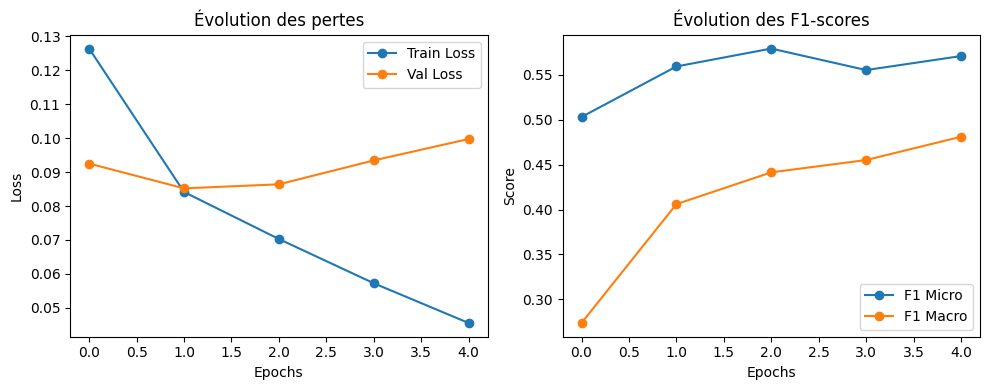

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# --- Loss ---
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss", marker='o')
plt.plot(history["val_loss"], label="Val Loss", marker='o')
plt.title("Évolution des pertes")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# --- F1 Scores ---
plt.subplot(1,2,2)
plt.plot(history["f1_micro"], label="F1 Micro", marker='o')
plt.plot(history["f1_macro"], label="F1 Macro", marker='o')
plt.title("Évolution des F1-scores")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.show()

**Tester le modèle sur de nouveaux textes**

In [17]:
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification

# Charger ton modèle fine-tuné
model_path = "bert_go_emotions_finetuned"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

# Liste des étiquettes GoEmotions (28 émotions)
labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring", "confusion",
    "curiosity", "desire", "disappointment", "disapproval", "disgust", "embarrassment",
    "excitement", "fear", "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

# Sélectionner quelques phrases du dataset test
num_examples = 5
samples = dataset['test'].select(range(num_examples))

print("=== 🔍 Évaluation qualitative du modèle ===\n")
for i in range(num_examples):
    text = samples[i]['text']
    # Correction : récupérer les indices directement
    true_labels = [labels[j] for j in samples[i]['labels']]

    # Tokenisation
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)

    # Prédiction
    with torch.no_grad():
        outputs = model(**inputs).logits
        probs = torch.sigmoid(outputs).cpu().numpy()[0]
        pred_indices = np.where(probs > 0.5)[0]
        pred_labels = [labels[j] for j in pred_indices]

    print(f"Texte : {text}")
    print(f"→ Émotions réelles : {true_labels}")
    print(f"→ Émotions prédites : {pred_labels}")
    print(f"→ Scores : {[round(probs[j], 2) for j in pred_indices]}")
    print("--------------------------------------------------")


=== 🔍 Évaluation qualitative du modèle ===

Texte : I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!
→ Émotions réelles : ['sadness']
→ Émotions prédites : ['remorse']
→ Scores : [0.61]
--------------------------------------------------
Texte : It's wonderful because it's awful. At not with.
→ Émotions réelles : ['admiration']
→ Émotions prédites : ['admiration', 'disgust']
→ Scores : [0.94, 0.71]
--------------------------------------------------
Texte : Kings fan here, good luck to you guys! Will be an interesting game to watch! 
→ Émotions réelles : ['excitement']
→ Émotions prédites : ['optimism']
→ Scores : [0.73]
--------------------------------------------------
Texte : I didn't know that, thank you for teaching me something today!
→ Émotions réelles : ['gratitude']
→ Émotions prédites : ['gratitude']
→ Scores : [1.0]
--------------------------------------------------
Texte : They got bored from haunting earth for thousands of y

In [18]:
def predict_emotion(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs).logits
        probs = torch.sigmoid(outputs).cpu().numpy()[0]
        pred_indices = np.where(probs > 0.5)[0]
        pred_labels = [labels[i] for i in pred_indices]
        scores = [round(probs[i], 2) for i in pred_indices]
    return list(zip(pred_labels, scores))

# Exemple interactif
while True:
    text = input("\nEntre une phrase (ou 'exit' pour quitter): ")
    if text.lower() == "exit":
        break
    preds = predict_emotion(text)
    if preds:
        print("→ Émotions prédites :", preds)
    else:
        print("→ Aucune émotion détectée.")



Entre une phrase (ou 'exit' pour quitter):  I’m so happy today!


→ Émotions prédites : [('joy', 0.93)]



Entre une phrase (ou 'exit' pour quitter):  exit
